# PowerLens — 02. EDA Univariée

> **KaynorData** · Descriptive Analytics · Energy Domain

---

## Objectif

Analyser chaque variable **indépendamment** pour comprendre :
- Sa distribution (forme, symétrie, outliers)
- Ses statistiques clés (moyenne, médiane, écart-type, quartiles)
- Son comportement temporel global


## 0. Imports & Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_parquet('../data/processed/powerlens_clean.parquet')
print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head(2)

Dataset chargé : 2,075,259 lignes × 17 colonnes


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,year,month,day,hour,day_of_week,day_name,month_name,is_weekend,quarter,energy_kwh
datetime,,,,,,,,,,,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006,12,16,17,5,Saturday,December,1,4,0.070267
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006,12,16,17,5,Saturday,December,1,4,0.089333


## 1. Statistiques descriptives globales

In [2]:
numeric_cols = [
    'Global_active_power', 'Global_reactive_power',
    'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

stats = df[numeric_cols].describe().T
stats['cv (%)'] = (stats['std'] / stats['mean'] * 100).round(1)  # Coefficient de variation
stats['median'] = df[numeric_cols].median()
stats['skewness'] = df[numeric_cols].skew().round(3)

stats[['count', 'mean', 'median', 'std', 'cv (%)', 'min', '25%', '75%', 'max', 'skewness']]

,count,mean,median,std,cv (%),min,25%,75%,max,skewness
Global_active_power,2075259.0,1.090280,0.614000,1.052628,96.5,0.076,0.310,1.528,11.122,1.792
Global_reactive_power,2075259.0,0.123649,0.100000,0.112419,90.9,0.000,0.048,0.194,1.390,1.263
Voltage,2075259.0,240.832785,241.000000,3.237763,1.3,223.200,238.990,242.870,254.150,-0.325
Global_intensity,2075259.0,4.621481,2.751585,4.424361,95.7,0.200,1.400,6.400,48.400,1.855
Sub_metering_1,2075259.0,1.109485,0.000000,6.115843,551.2,0.000,0.000,0.000,88.000,5.984
Sub_metering_2,2075259.0,1.289229,0.000000,5.786613,448.8,0.000,0.000,1.000,80.000,7.136
Sub_metering_3,2075259.0,6.442386,1.000000,8.415860,130.6,0.000,0.000,17.000,31.000,0.730


## 2. Distribution de la puissance active globale

> Variable principale : `Global_active_power` (kW)

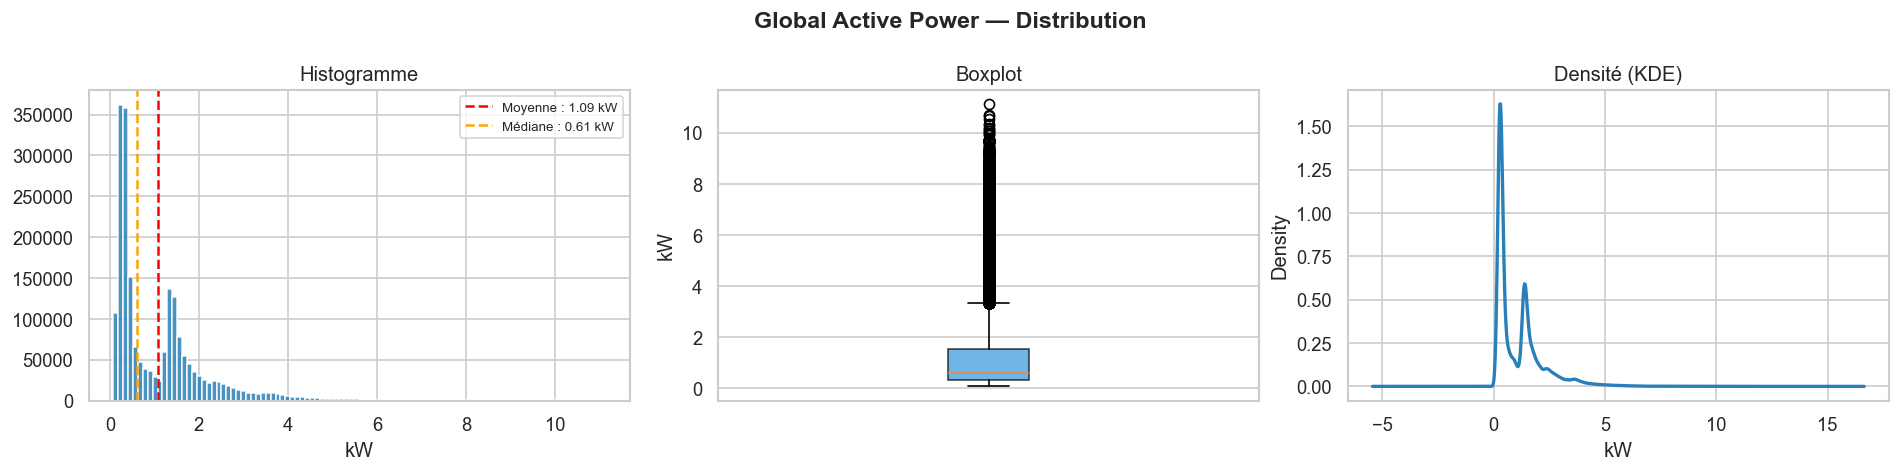

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Global Active Power — Distribution', fontsize=14, fontweight='bold')

# Histogramme
axes[0].hist(df['Global_active_power'], bins=100, color='#2980b9', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Global_active_power'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['Global_active_power'].mean():.2f} kW")
axes[0].axvline(df['Global_active_power'].median(), color='orange', linestyle='--', label=f"Médiane : {df['Global_active_power'].median():.2f} kW")
axes[0].set_title('Histogramme')
axes[0].set_xlabel('kW')
axes[0].legend(fontsize=8)

# Boxplot
axes[1].boxplot(df['Global_active_power'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_title('Boxplot')
axes[1].set_ylabel('kW')
axes[1].set_xticks([])

# KDE
df['Global_active_power'].plot.kde(ax=axes[2], color='#2980b9', linewidth=2)
axes[2].set_title('Densité (KDE)')
axes[2].set_xlabel('kW')

plt.tight_layout()
plt.savefig('../reports/figures/02_gap_distribution.png', dpi=150)
plt.show()

## 3. Distribution de toutes les variables numériques

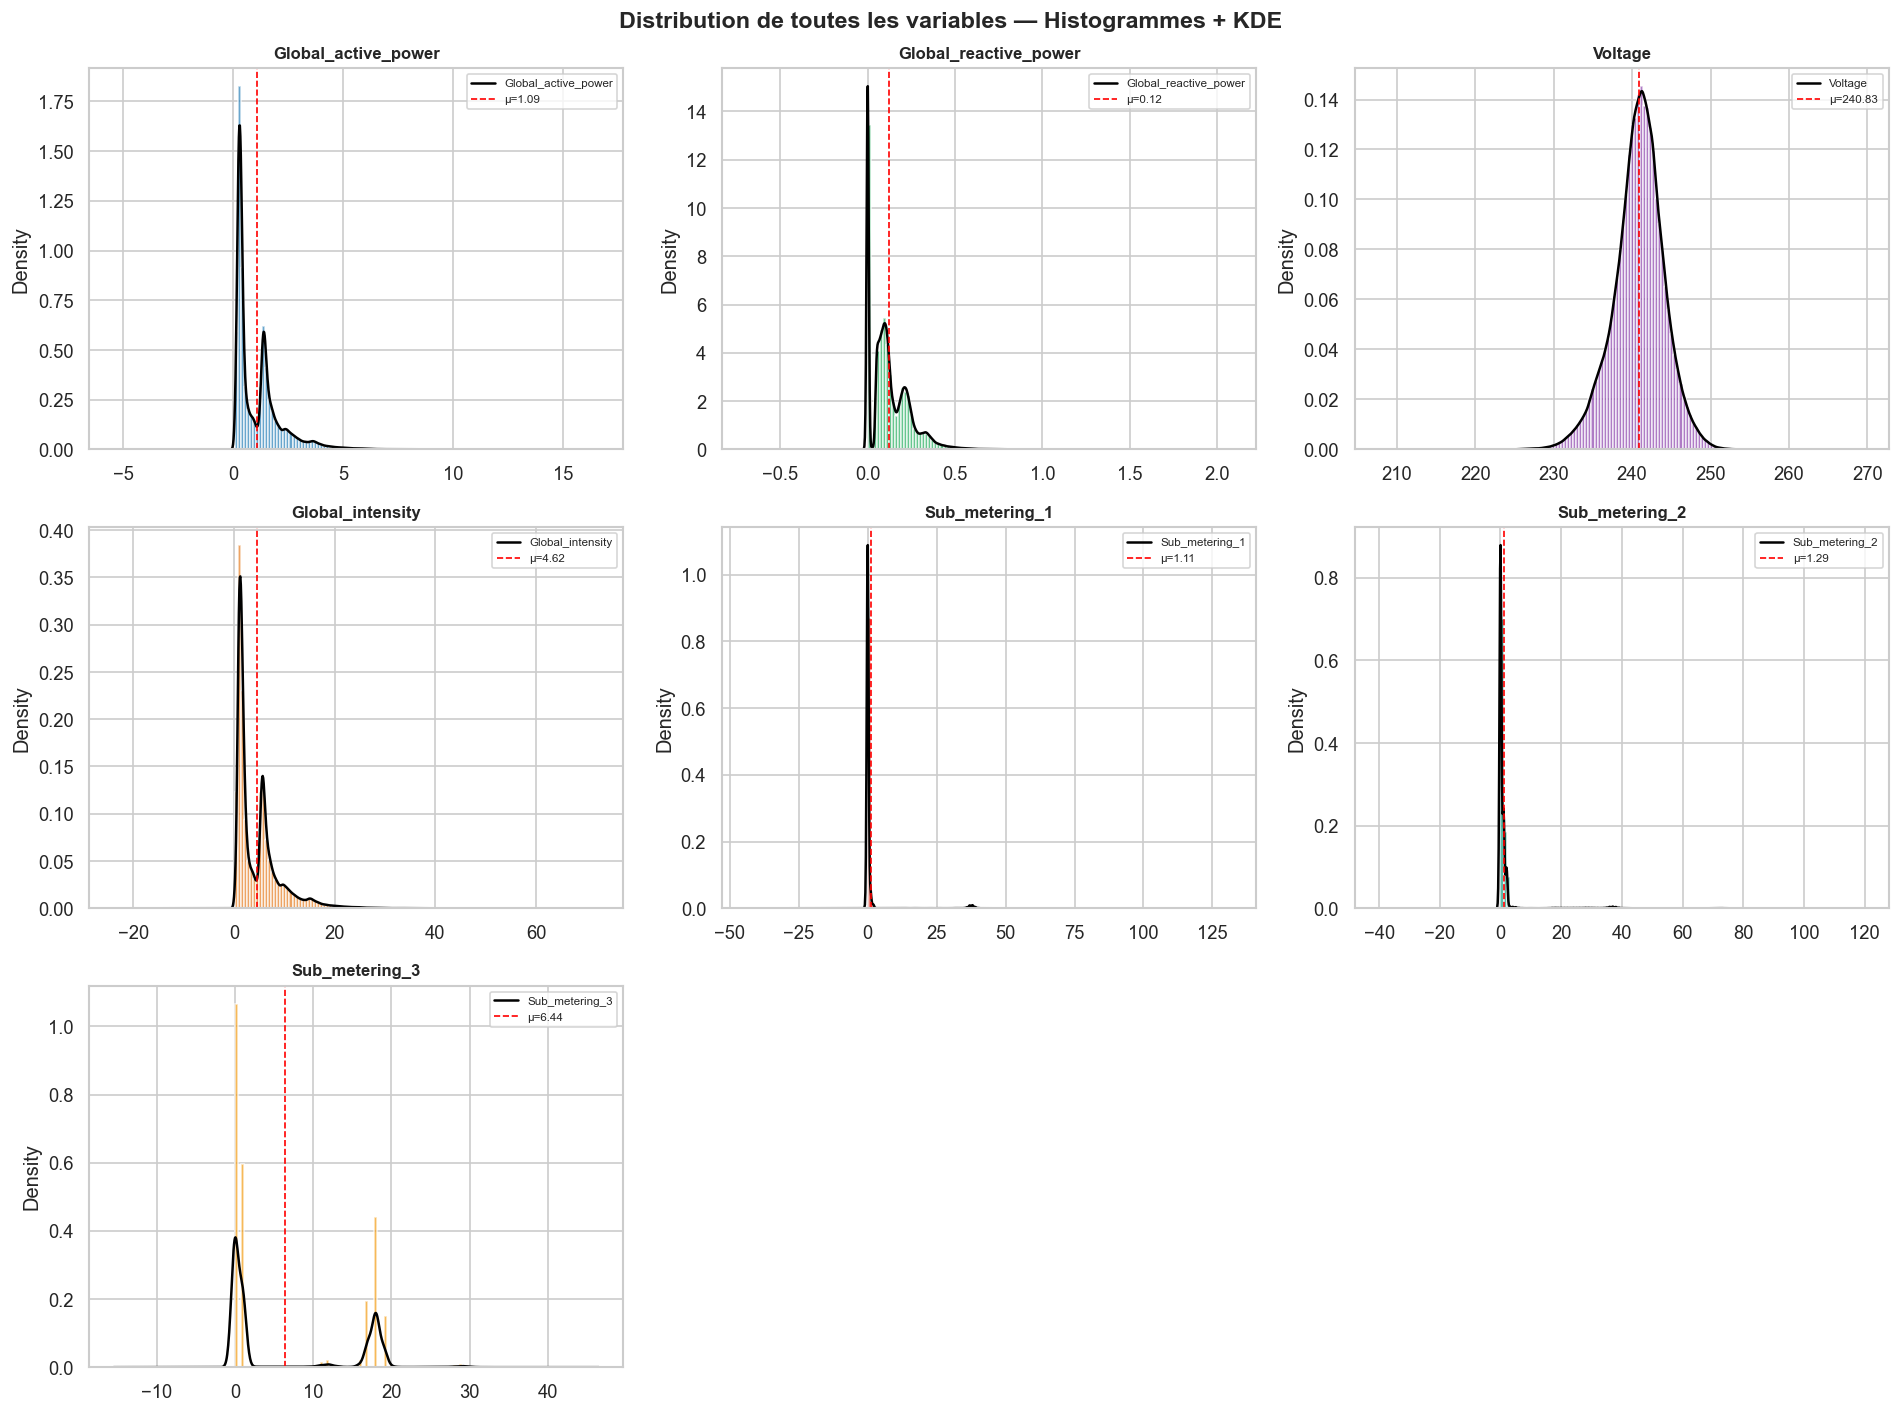

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Distribution de toutes les variables — Histogrammes + KDE', fontsize=14, fontweight='bold')
axes = axes.flatten()

colors = ['#2980b9', '#27ae60', '#8e44ad', '#e67e22', '#e74c3c', '#16a085', '#f39c12']

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=80, color=colors[i], edgecolor='white', alpha=0.7, density=True)
    data.plot.kde(ax=ax, color='black', linewidth=1.5)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1, label=f'μ={data.mean():.2f}')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('')

# Cacher les axes inutilisés
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/02_all_distributions.png', dpi=150)
plt.show()

## 4. Boxplots comparatifs — Toutes les variables

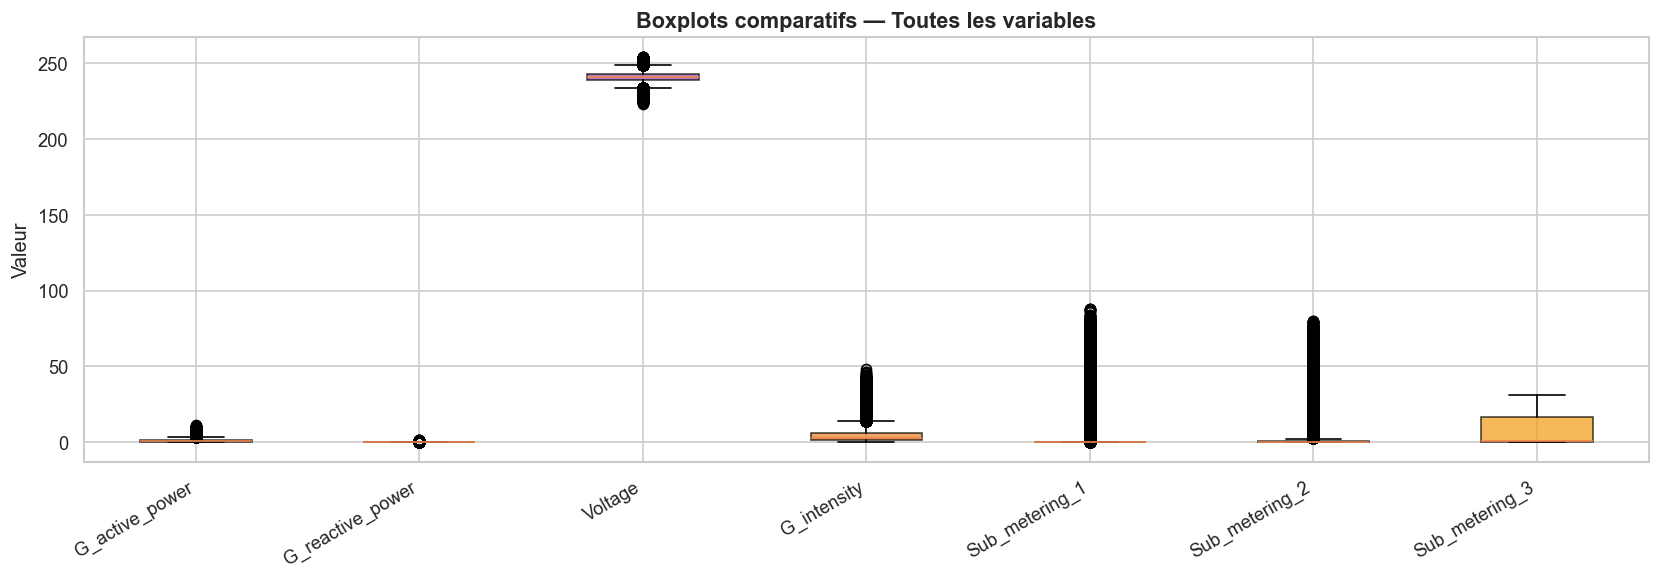

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))

data_to_plot = [df[col].dropna().values for col in numeric_cols]
bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(numeric_cols) + 1))
ax.set_xticklabels([c.replace('Global_', 'G_') for c in numeric_cols], rotation=30, ha='right')
ax.set_title('Boxplots comparatifs — Toutes les variables', fontsize=13, fontweight='bold')
ax.set_ylabel('Valeur')

plt.tight_layout()
plt.savefig('../reports/figures/02_boxplots_all.png', dpi=150)
plt.show()

## 5. Évolution temporelle globale — Consommation par jour

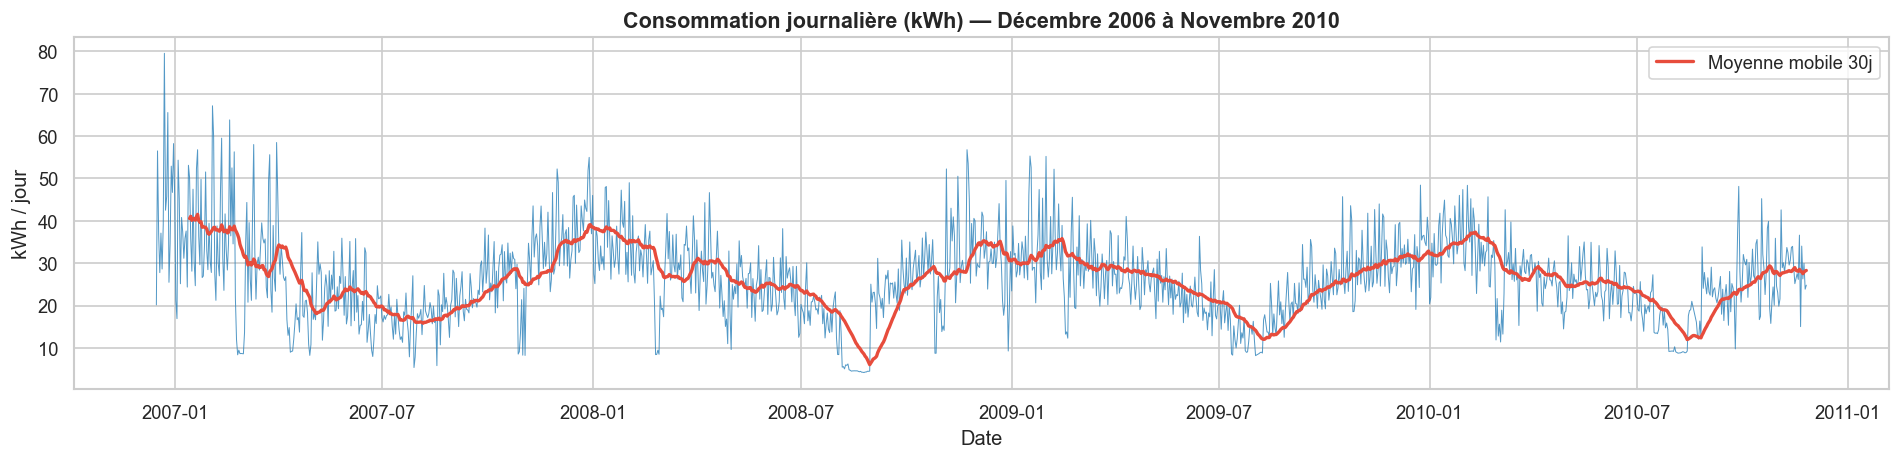

In [6]:
# Resampler à la journée (somme en kWh)
daily = df['energy_kwh'].resample('D').sum()

fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(daily.index, daily.values, color='#2980b9', linewidth=0.6, alpha=0.8)

# Moyenne mobile 30 jours
rolling_mean = daily.rolling(30).mean()
ax.plot(rolling_mean.index, rolling_mean.values, color='#e74c3c', linewidth=2, label='Moyenne mobile 30j')

ax.set_title('Consommation journalière (kWh) — Décembre 2006 à Novembre 2010', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('kWh / jour')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/02_daily_consumption_trend.png', dpi=150)
plt.show()

## 6. Distribution de la consommation par année

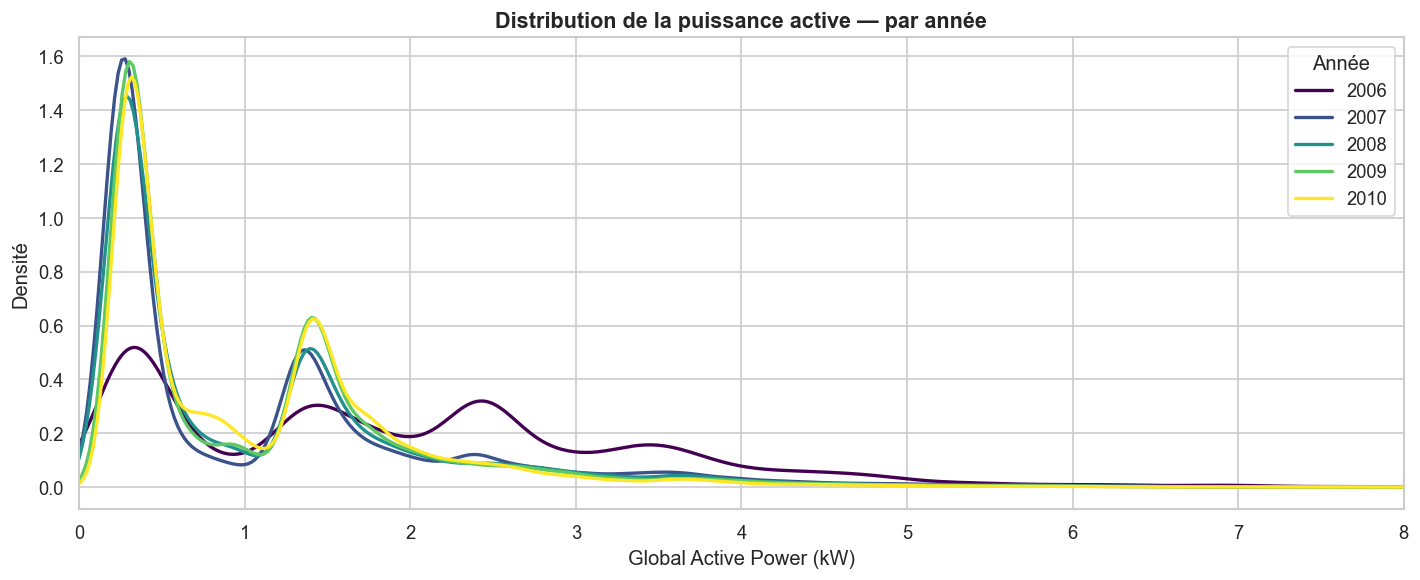

In [8]:
import matplotlib.cm as cm
import numpy as np

years = sorted(df['year'].unique())

colors = cm.viridis(np.linspace(0, 1, len(years)))

fig, ax = plt.subplots(figsize=(12, 5))

for i, year in enumerate(years):
    data = df[df['year'] == year]['Global_active_power'].dropna()
    data.plot.kde(ax=ax, label=str(year), color=colors[i], linewidth=2)

ax.set_title('Distribution de la puissance active — par année', fontsize=13, fontweight='bold')
ax.set_xlabel('Global Active Power (kW)')
ax.set_ylabel('Densité')
ax.legend(title='Année')
ax.set_xlim(0, 8)

plt.tight_layout()
plt.savefig('../reports/figures/02_distribution_by_year.png', dpi=150)
plt.show()

## 7. Résumé des observations

| Variable | Observation clé |
|----------|-----------------|
| `Global_active_power` | Distribution asymétrique à droite (skewed right) — majorité des valeurs entre 0 et 2 kW |
| `Voltage` | Distribution quasi-normale, centrée autour de 240V |
| `Sub_metering_3` | Bimodale — indique des appareils ON/OFF (chauffe-eau, climatisation) |
| Trend journalier | Saisonnalité visible — consommation plus élevée en hiver |

---
**Prochain notebook :** `03_eda_bivariate.ipynb` — Corrélations, patterns temporels, heatmaps